### Setup & Imports

In [2]:
# Here I want to import everything I need for trying out preprocessing
# and filters on some sample images.

import os
import sys
import numpy as np
import matplotlib.pyplot as plt

project_root = r"C:\Users\Arafat\Desktop\IMA Project"
if project_root not in sys.path:
    sys.path.append(project_root)

from src import config
from src import preprocessing
from src import filters as my_filters
from src import data_loading
from src.utils import set_random_seed

from skimage import io

config.make_all_dirs()
set_random_seed(42)


[utils] Random seed set to 42


### Load Split CSV & Select Sample Images

In [3]:
# I load my split info so I can pick some example images.
df_splits = data_loading.load_splits_csv()

print(df_splits.head())

# I take 6 random images from the training set.
df_sample = df_splits[df_splits["split"] == "train"].sample(n=6, random_state=42)

sample_paths = df_sample["filepath"].tolist()
sample_labels = df_sample["label"].tolist()

print("Chosen sample images:")
for p, l in zip(sample_paths, sample_labels):
    print(l, "->", p)


[data_loading] Loading split CSV from C:\Users\Arafat\Desktop\IMA Project\data\processed\splits\split_info.csv
[data_loading] Loaded DataFrame shape: (12444, 3)
                                            filepath       label  split
0  C:\Users\Arafat\Desktop\IMA Project\data\raw\T...  NEUTROPHIL  train
1  C:\Users\Arafat\Desktop\IMA Project\data\raw\T...    MONOCYTE  train
2  C:\Users\Arafat\Desktop\IMA Project\data\raw\T...  LYMPHOCYTE  train
3  C:\Users\Arafat\Desktop\IMA Project\data\raw\T...  EOSINOPHIL  train
4  C:\Users\Arafat\Desktop\IMA Project\data\raw\T...  EOSINOPHIL  train
Chosen sample images:
EOSINOPHIL -> C:\Users\Arafat\Desktop\IMA Project\data\raw\TRAIN\EOSINOPHIL\_42_5842.jpeg
LYMPHOCYTE -> C:\Users\Arafat\Desktop\IMA Project\data\raw\TRAIN\LYMPHOCYTE\_8_9216.jpeg
EOSINOPHIL -> C:\Users\Arafat\Desktop\IMA Project\data\raw\TEST\EOSINOPHIL\_6_9405.jpeg
EOSINOPHIL -> C:\Users\Arafat\Desktop\IMA Project\data\raw\TRAIN\EOSINOPHIL\_2_6900.jpeg
EOSINOPHIL -> C:\Users\Arafat

### Function to show image grids

In [4]:
# Here I write a helper to show multiple images in a grid.

def show_images(img_list, titles_list=None, ncols=3, figsize=(12, 6), main_title=""):
    n = len(img_list)
    nrows = int(np.ceil(n / ncols))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(img_list[i], cmap="gray")
        plt.axis("off")
        if titles_list:
            plt.title(titles_list[i])
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()


### visualizing original sample images

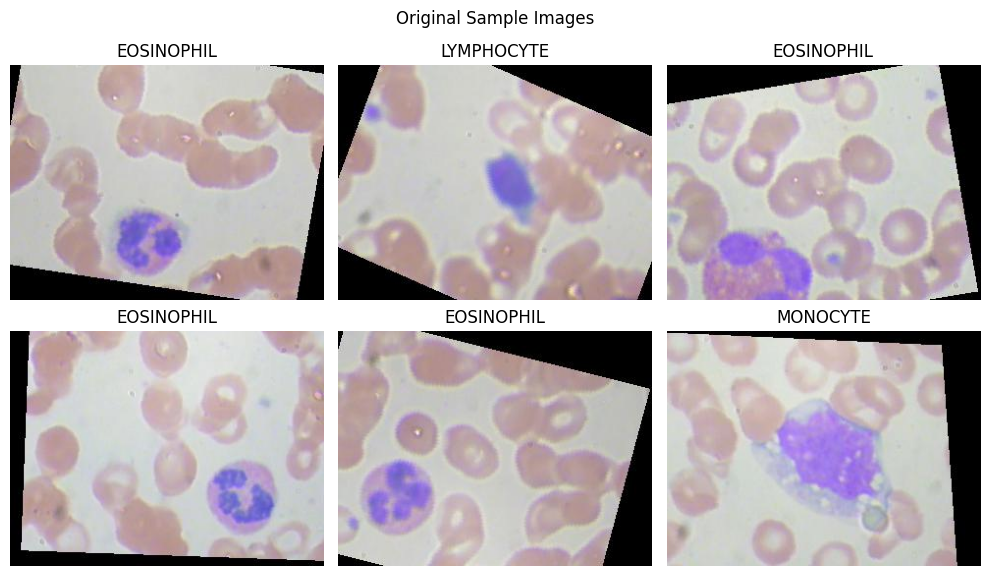

In [5]:
# I show the images exactly as they are in the dataset.

original_imgs = [io.imread(path) for path in sample_paths]
titles = sample_labels

show_images(original_imgs, titles, ncols=3, figsize=(10, 6), main_title="Original Sample Images")


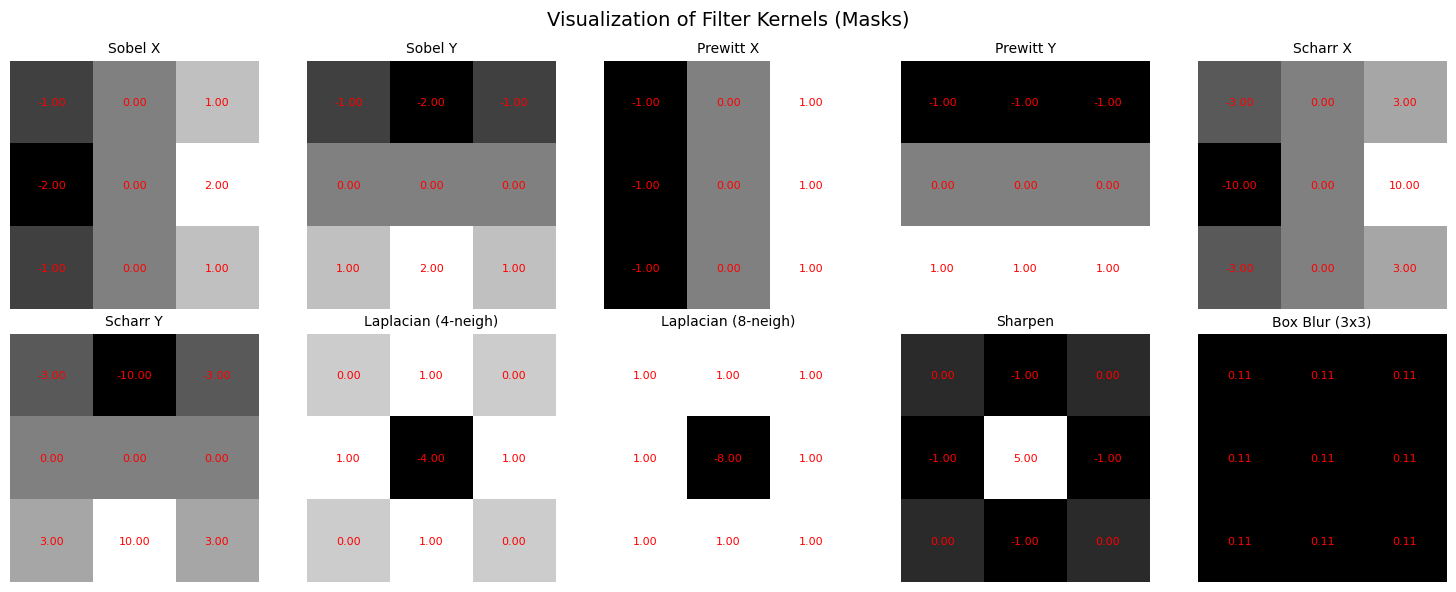

In [6]:
# I want to visualize the filters also
import numpy as np
import matplotlib.pyplot as plt


def visualize_filter_kernels():
    """
    Here I want to visualize the actual filter kernels as small images.
    """

    # Classic edge filters (3x3)
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]], dtype=float)

    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]], dtype=float)

    prewitt_x = np.array([[-1, 0, 1],
                          [-1, 0, 1],
                          [-1, 0, 1]], dtype=float)

    prewitt_y = np.array([[-1, -1, -1],
                          [ 0,  0,  0],
                          [ 1,  1,  1]], dtype=float)

    scharr_x = np.array([[-3, 0, 3],
                         [-10, 0, 10],
                         [-3, 0, 3]], dtype=float)

    scharr_y = np.array([[-3, -10, -3],
                         [ 0,   0,  0],
                         [ 3,  10,  3]], dtype=float)

    # Laplacian kernels 
    laplacian_4 = np.array([[0,  1, 0],
                            [1, -4, 1],
                            [0,  1, 0]], dtype=float)

    laplacian_8 = np.array([[1,  1, 1],
                            [1, -8, 1],
                            [1,  1, 1]], dtype=float)

    # sharpening kernel
    sharpen = np.array([[ 0, -1,  0],
                        [-1,  5, -1],
                        [ 0, -1,  0]], dtype=float)

    # Simple box blur kernel which is mean filter
    box_3 = (1/9) * np.ones((3, 3), dtype=float)

    kernel_dict = {
        "Sobel X": sobel_x,
        "Sobel Y": sobel_y,
        "Prewitt X": prewitt_x,
        "Prewitt Y": prewitt_y,
        "Scharr X": scharr_x,
        "Scharr Y": scharr_y,
        "Laplacian (4-neigh)": laplacian_4,
        "Laplacian (8-neigh)": laplacian_8,
        "Sharpen": sharpen,
        "Box Blur (3x3)": box_3,
    }

    # Ploting them in a grid
    names = list(kernel_dict.keys())
    kernels = list(kernel_dict.values())

    n = len(kernels)
    ncols = 5
    nrows = int(np.ceil(n / ncols))

    plt.figure(figsize=(3*ncols, 3*nrows))

    for i in range(n):
        plt.subplot(nrows, ncols, i+1)
        plt.imshow(kernels[i], cmap="gray")
        plt.title(names[i], fontsize=10)
        plt.axis("off")

        # show numbers on top of cells
        for r in range(kernels[i].shape[0]):
            for c in range(kernels[i].shape[1]):
                plt.text(c, r, f"{kernels[i][r,c]:.2f}",
                         ha="center", va="center",
                         color="red", fontsize=8)

    plt.suptitle("Visualization of Filter Kernels (Masks)", fontsize=14)
    plt.tight_layout()
    plt.show()


visualize_filter_kernels()


### preprocessing resize -> gray -> gaussian -> CLAHE Pipeline

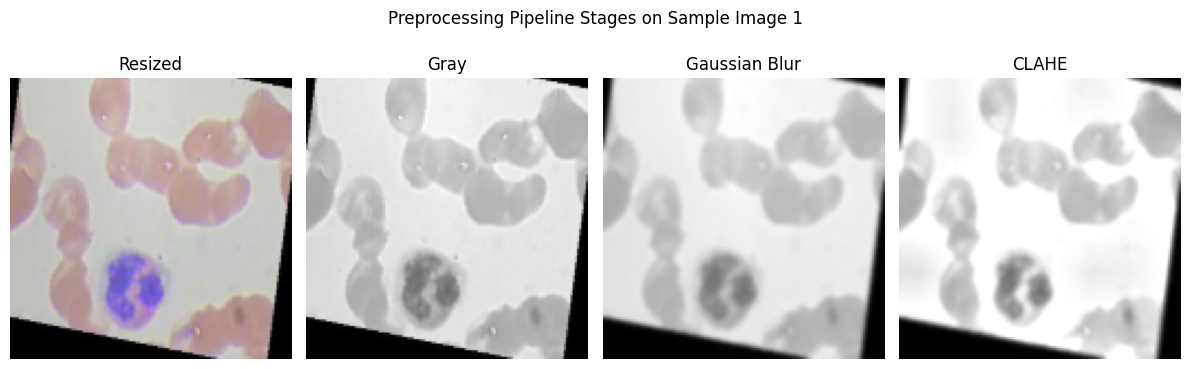

In [7]:
# I want to show how my preprocessing pipeline transforms images step by step.

preprocessed_imgs = []
pipeline_steps_visualization = []

for path in sample_paths:
    temp_img = preprocessing.load_image_as_float(path)
    resized_img = preprocessing.resize_image(temp_img)
    gray_img = preprocessing.to_grayscale(resized_img)
    gauss_img = preprocessing.apply_gaussian_blur(gray_img, sigma_value=1.0)
    clahe_img = preprocessing.apply_clahe_on_gray(gauss_img, clip_limit=0.01)

    preprocessed_imgs.append(clahe_img)
    pipeline_steps_visualization.append([resized_img, gray_img, gauss_img, clahe_img])

# now visualizing one complete pipeline on the first image
labels = ["Resized", "Gray", "Gaussian Blur", "CLAHE"]
show_images(pipeline_steps_visualization[0], labels, ncols=4, figsize=(12, 4),
            main_title="Preprocessing Pipeline Stages on Sample Image 1")


### compare original vs fully preprocessed

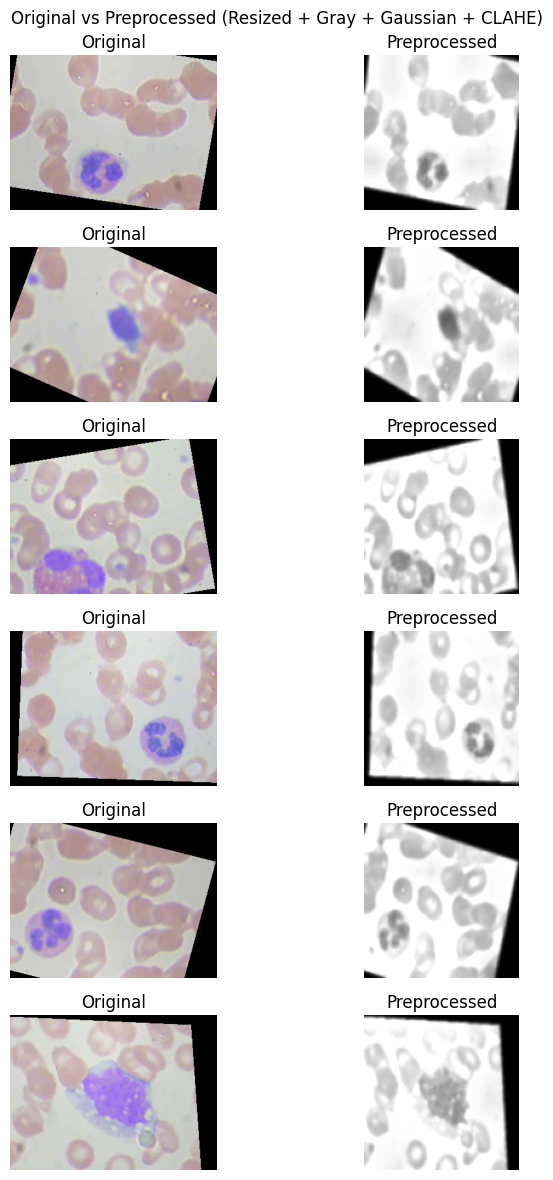

In [8]:
# I compare original images vs the final preprocessed grayscale images.

compare_imgs = []
compare_titles = []

for orig, pre in zip(original_imgs, preprocessed_imgs):
    compare_imgs += [orig, pre]
    compare_titles += ["Original", "Preprocessed"]

show_images(compare_imgs, compare_titles, ncols=2, figsize=(8, 12),
            main_title="Original vs Preprocessed (Resized + Gray + Gaussian + CLAHE)")


### filters like sobel, prewitt, scharr, laplacian, LoG, canny

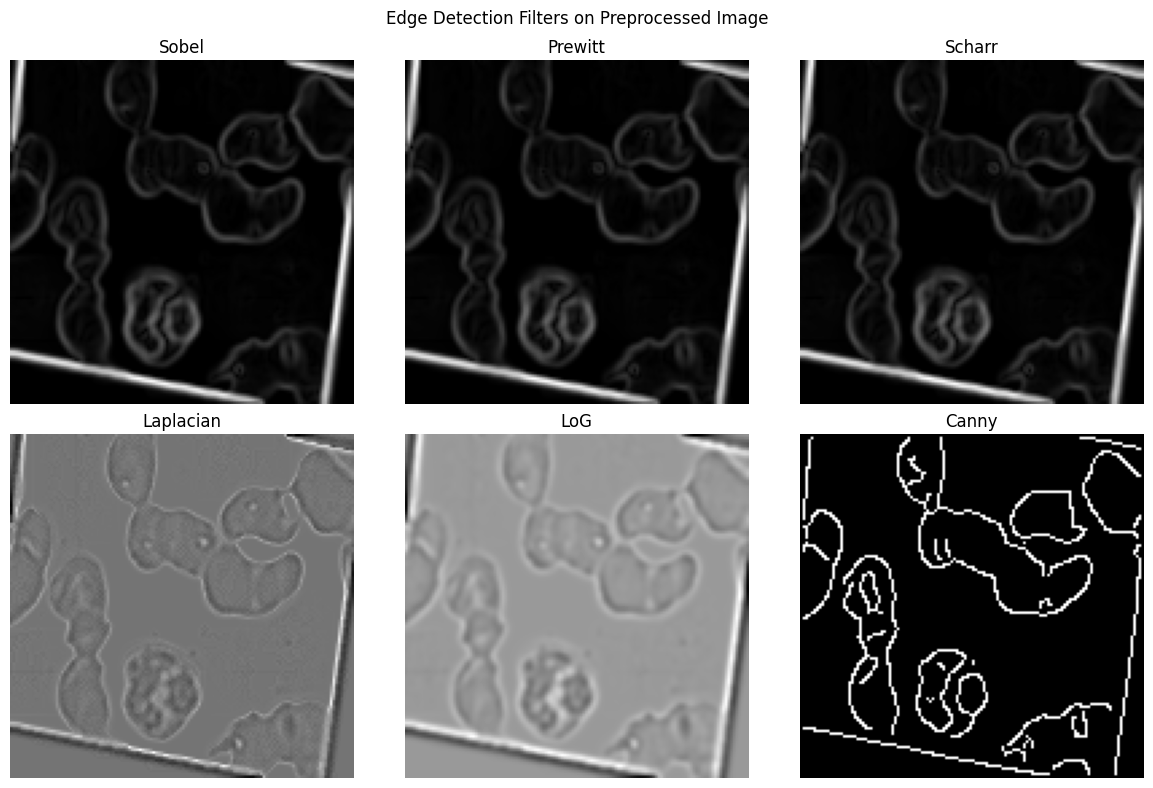

In [9]:
# Here I apply several edge filters to demonstrate how they react.

filter_results = []
filter_names = ["Sobel", "Prewitt", "Scharr", "Laplacian", "LoG", "Canny"]

# For visualization I use the first preprocessed image
demo_img = preprocessed_imgs[0]

sob = my_filters.sobel_magnitude(demo_img)
pre = my_filters.prewitt_magnitude(demo_img)
sch = my_filters.scharr_magnitude(demo_img)
lap = my_filters.laplacian_filter(demo_img)
logf = my_filters.log_edges(demo_img, sigma_value=1.0)
can = my_filters.canny_edges(demo_img, sigma_value=1.0)

filter_results = [sob, pre, sch, lap, logf, can]

show_images(filter_results, filter_names, ncols=3, figsize=(12, 8),
            main_title="Edge Detection Filters on Preprocessed Image")


### morphology like binary, opening, closing, morph gradient

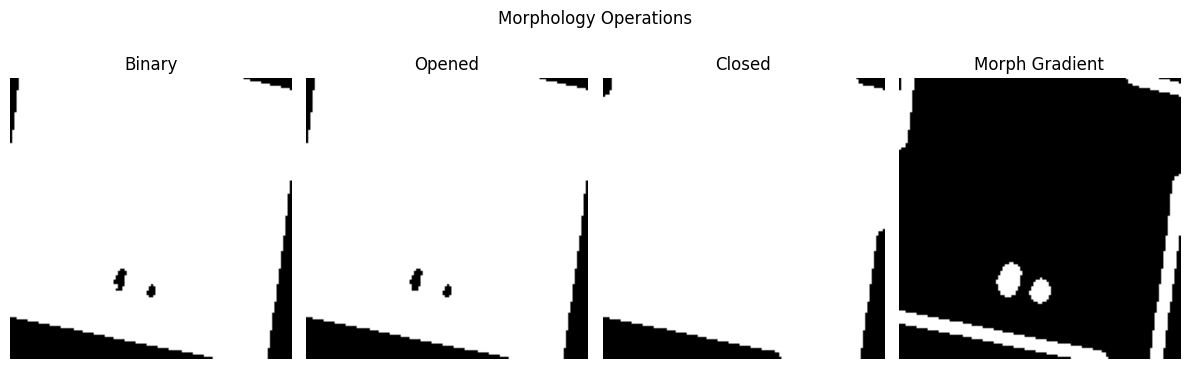

In [10]:
# visualizing morphology operations.

morph_dict = my_filters.basic_morphology_ops(demo_img, disk_size=3)
morph_imgs = [morph_dict["binary"], morph_dict["opened"], morph_dict["closed"], morph_dict["morph_gradient"]]
morph_titles = ["Binary", "Opened", "Closed", "Morph Gradient"]

show_images(morph_imgs, morph_titles, ncols=4, figsize=(12, 4),
            main_title="Morphology Operations")


### Fourier Magnitude Spectrum Visualization

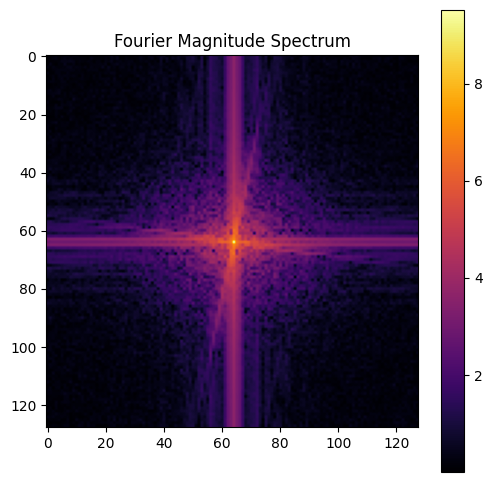

In [11]:
# Here I show the Fourier magnitude spectrum for the same image.

fft_mag = my_filters.fft_magnitude_spectrum(demo_img)

plt.figure(figsize=(6,6))
plt.imshow(fft_mag, cmap='inferno')
plt.title("Fourier Magnitude Spectrum")
plt.colorbar()
plt.show()


### low frequency center

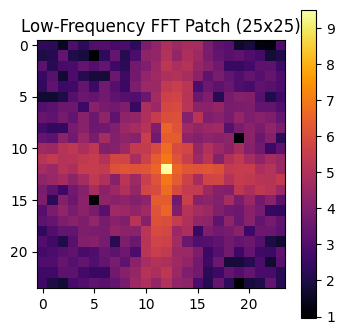

In [12]:
# to visualize the low frequency patch extracted from FFT.

low_freq_patch = my_filters.fft_low_freq_patch(demo_img, patch_size=25)

plt.figure(figsize=(4,4))
plt.imshow(low_freq_patch, cmap='inferno')
plt.title("Low-Frequency FFT Patch (25x25)")
plt.colorbar()
plt.show()


### radial FFT energy distribution

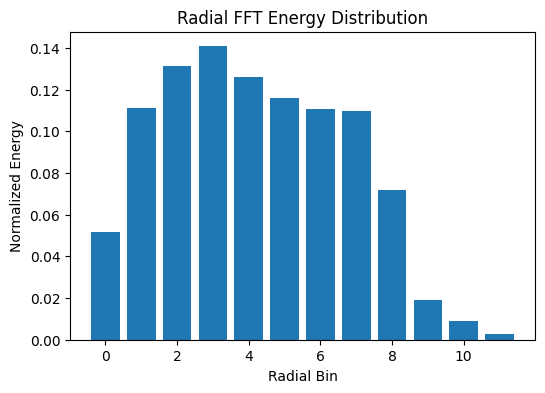

In [13]:
# visualizing the radial FFT energy descriptor

radial = my_filters.fft_radial_energy(demo_img, num_bins=12)

plt.figure(figsize=(6,4))
plt.bar(range(len(radial)), radial)
plt.title("Radial FFT Energy Distribution")
plt.xlabel("Radial Bin")
plt.ylabel("Normalized Energy")
plt.show()


### DCT low frequency block

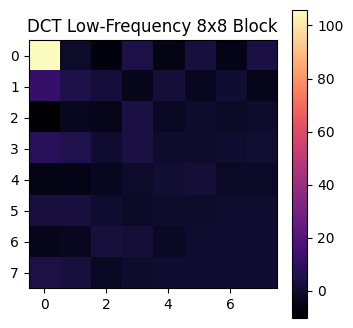

In [14]:
# Displaying the DCT low frequency block

dct_block = my_filters.dct_low_freq_block(demo_img, block_size=8)

plt.figure(figsize=(4,4))
plt.imshow(dct_block, cmap='magma')
plt.title("DCT Low-Frequency 8x8 Block")
plt.colorbar()
plt.show()


### visualizing LBP image

C:\Users\Arafat\AppData\Local\Programs\Python\Python312\Lib\site-packages\skimage\feature\texture.py:360: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


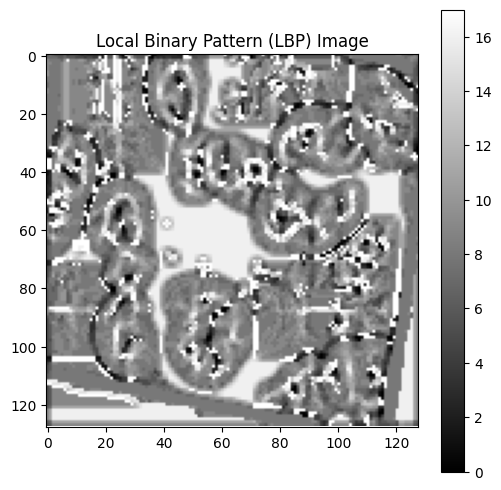

In [15]:
from skimage.feature import local_binary_pattern

lbp_img = local_binary_pattern(demo_img, P=16, R=2, method='uniform')

plt.figure(figsize=(6,6))
plt.imshow(lbp_img, cmap='gray')
plt.title("Local Binary Pattern (LBP) Image")
plt.colorbar()
plt.show()
